In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import subprocess

plt.style.use('seaborn-v0_8-whitegrid')

# make research/ importable when running from research/
sys.path.insert(0, os.path.abspath('.'))

from ou_calibration import calibrate_ou
from ofi_signal    import analyze_ofi
from frontier      import run_frontier, plot_frontier

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../data/processed',  exist_ok=True)
print('Setup complete.')

Setup complete.


**Data.** LOBSTER AAPL Level-10 order book data, June 21 2012 (~400k tick events). AAPL daily closing prices 2010–2012 via yfinance for OU calibration.

**Core hedge inequality:**

$$\text{Hedge} \iff \underbrace{\frac{1}{2}\,|\Gamma|\, S^2\, \sigma^2\, \Delta t}_{\text{gamma risk from waiting}} > \lambda \times \underbrace{\Delta_{\text{shares}} \times \frac{\text{spread}}{2}}_{\text{cost of hedging now}}$$

In [ ]:
# sim output
tick_log  = pd.read_csv('../data/processed/tick_log.csv')
hedge_log = pd.read_csv('../data/processed/hedge_log.csv')
summary   = pd.read_csv('../data/processed/summary.csv')

s = summary.iloc[0]

avg_spread_bps = (tick_log['spread'] / tick_log['mid_price'] * 10000).mean()

log_rets    = np.log(tick_log['mid_price'] / tick_log['mid_price'].shift(1)).dropna()
avg_dt      = tick_log['timestamp'].diff().mean()
rv_intraday = log_rets.std() * np.sqrt(252 * 6.5 * 3600 / avg_dt)

print('=== Simulation Summary (lambda = 1.0) ===')
print(f'  Tick events processed      : {int(s["total_events"]):>10,}')
print(f'  Hedges executed            : {int(s["total_hedges"]):>10,}')
print(f'  Avg bid-ask spread         : ${s["avg_spread"]:>10.4f}  ({avg_spread_bps:.1f} bps)')
print(f'  Avg time between hedges    : {s["avg_time_between_hedges"]:>10.1f} s')
print(f'  Cumulative theta P&L       : ${s["total_theta_pnl"]:>+10.2f}')
print(f'  Cumulative gamma P&L       : ${s["total_gamma_pnl"]:>+10.2f}')
print(f'  Total transaction costs    : ${s["total_tcost"]:>10.2f}')
print(f'  MTM P&L (primary)          : ${s["mtm_pnl"]:>+10.2f}')
print(f'  Greek net P&L (approx)     : ${s["greek_net_pnl"]:>+10.2f}')
print()
print('=== AAPL Intraday Statistics ===')
print(f'  Opening mid price          : ${tick_log["mid_price"].iloc[0]:>10.4f}')
print(f'  Closing mid price          : ${tick_log["mid_price"].iloc[-1]:>10.4f}')
print(f'  Intraday range             :  ${tick_log["mid_price"].min():.4f} / ${tick_log["mid_price"].max():.4f}')
print(f'  Total price move           : ${abs(tick_log["mid_price"].iloc[-1] - tick_log["mid_price"].iloc[0]):>10.4f}')
print(f'  Realized vol (annualised)  : {rv_intraday:>10.4f}  ({rv_intraday*100:.1f}%)')

print('Note: MTM P&L = straddle value change + hedge inventory + hedge cash flows.')
print('      It captures delta P&L between hedges, which the greek decomposition omits.')

=== Simulation Summary (lambda = 1.0) ===
  Tick events processed      :    400,391
  Hedges executed            :        665
  Avg bid-ask spread         : $    0.1535  (2.6 bps)
  Avg time between hedges    :       35.0 s
  Cumulative theta P&L       : $    +15.04
  Cumulative gamma P&L       : $    -43.66
  Total transaction costs    : $     38.04
  MTM P&L (primary)          : $    -48.18
  Greek net P&L (approx)     : $    -66.66

=== AAPL Intraday Statistics ===
  Opening mid price          : $  585.6350
  Closing mid price          : $  577.6050
  Intraday range             :  $577.4800 / $588.1850
  Total price move           : $    8.0300
  Realized vol (annualised)  :     0.1840  (18.4%)
Note: MTM P&L = straddle value change + hedge inventory + hedge cash flows.
      It captures delta P&L between hedges, which the greek decomposition omits.


  623 daily observations downloaded
  602 realized-vol observations after dropping NaN
  Vol range: [0.0724, 0.4805]

=== Ornstein-Uhlenbeck Calibration Results ===
  κ (kappa) =   6.0633  — mean reversion speed (half-life = 28.8 trading days)
  θ (theta) =   0.2474  — long-run mean volatility  (24.7%)
  ξ (xi)    =   0.2885  — vol of vol
  R²        = 0.9549

Figure saved → ../results/figures/ou_calibration.png

=== OU Parameter Table ===
Parameter    Value                                   Interpretation
    kappa 6.063260 Mean reversion speed — half-life 29 trading days
    theta 0.247432 Long-run mean vol = 24.7%  (simulation uses 25%)
       xi 0.288481                              Vol of vol = 0.2885


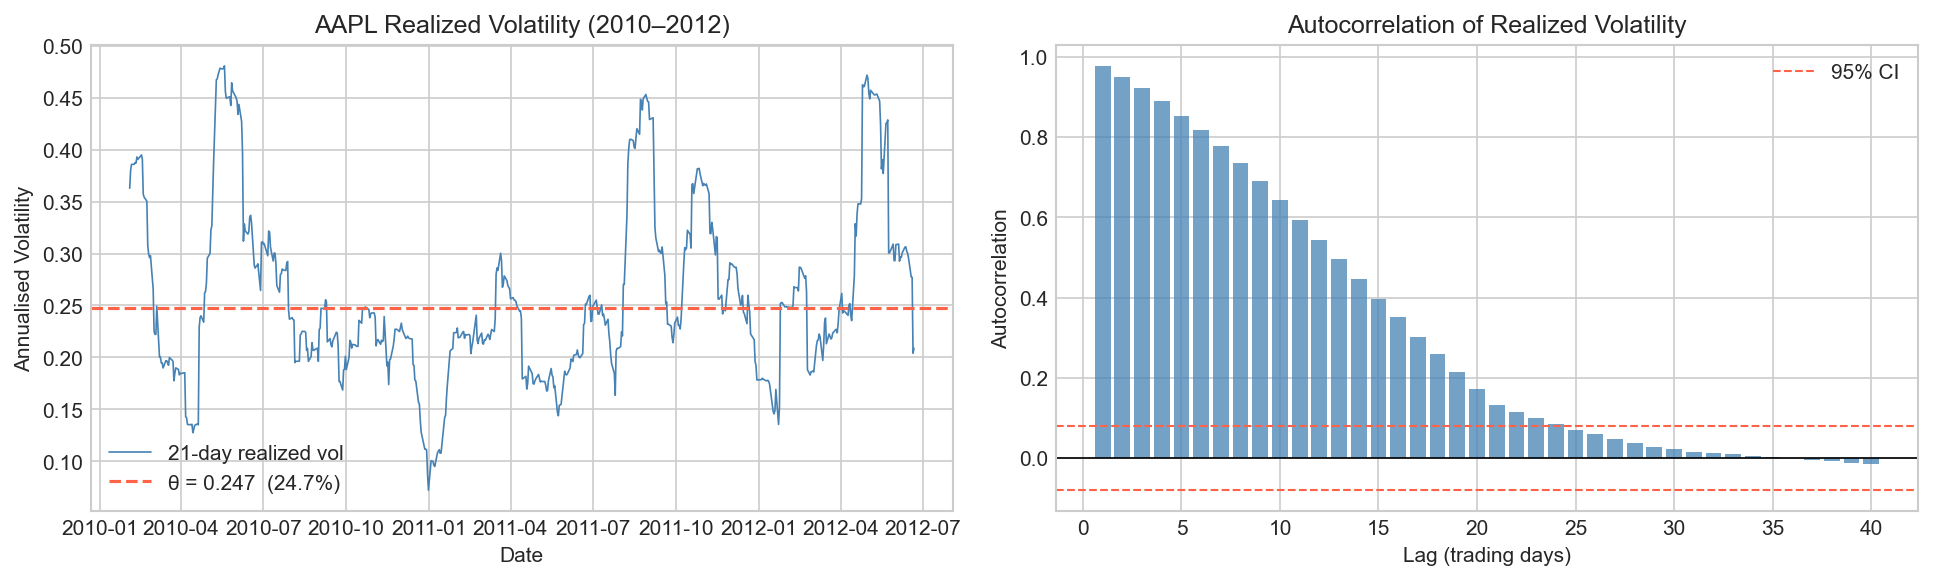

In [ ]:
# OU calibration
ou_params = calibrate_ou(save_fig=True)

print('\n=== OU Parameter Table ===')
param_df = pd.DataFrame({
    'Parameter': ['kappa', 'theta', 'xi'],
    'Value':     [ou_params['kappa'], ou_params['theta'], ou_params['xi']],
    'Interpretation': [
        f"Mean reversion speed — half-life {np.log(2)/ou_params['kappa']*252:.0f} trading days",
        f"Long-run mean vol = {ou_params['theta']*100:.1f}%  (simulation uses 25%)",
        f"Vol of vol = {ou_params['xi']:.4f}",
    ]
})
print(param_df.to_string(index=False))

from IPython.display import Image, display
display(Image('../results/figures/ou_calibration.png'))

**Interpretation.** A positive κ confirms mean reversion: volatility does not random-walk indefinitely, it reverts toward θ after spikes. θ being close to 25% means the engine is operating near the long-run neutral vol regime. ξ represents vol-of-vol: higher ξ means the future vol path is less certain and the optimal hedge bandwidth should be wider.

Loading hedge log from ../data/processed/hedge_log.csv...
  665 total hedge events
  533 after excluding zero-OFI rows

=== OFI Execution Analysis ===
                            Favorable  Unfavorable
──────────────────────────────────────────────────
Count                             217          316
Mean slip/share ($)            0.0512       0.0604
Median slip/share ($)          0.0450       0.0600
Total slippage ($)            11.1200      19.0900

  t-stat = -3.086,  p = 0.0021  (significant at α = 0.05)
  Mean slippage improvement with favorable OFI: +15.3%

Figure saved → ../results/figures/ofi_analysis.png

=== OFI Results ===
               Metric Favorable OFI Unfavorable OFI
                Count           217             316
  Mean slip/share ($)        0.0512          0.0604
Median slip/share ($)        0.0450          0.0600
   Total slippage ($)       11.1200         19.0900

Slippage improvement : 15.3%
t-statistic          : -3.086
p-value              : 0.0021


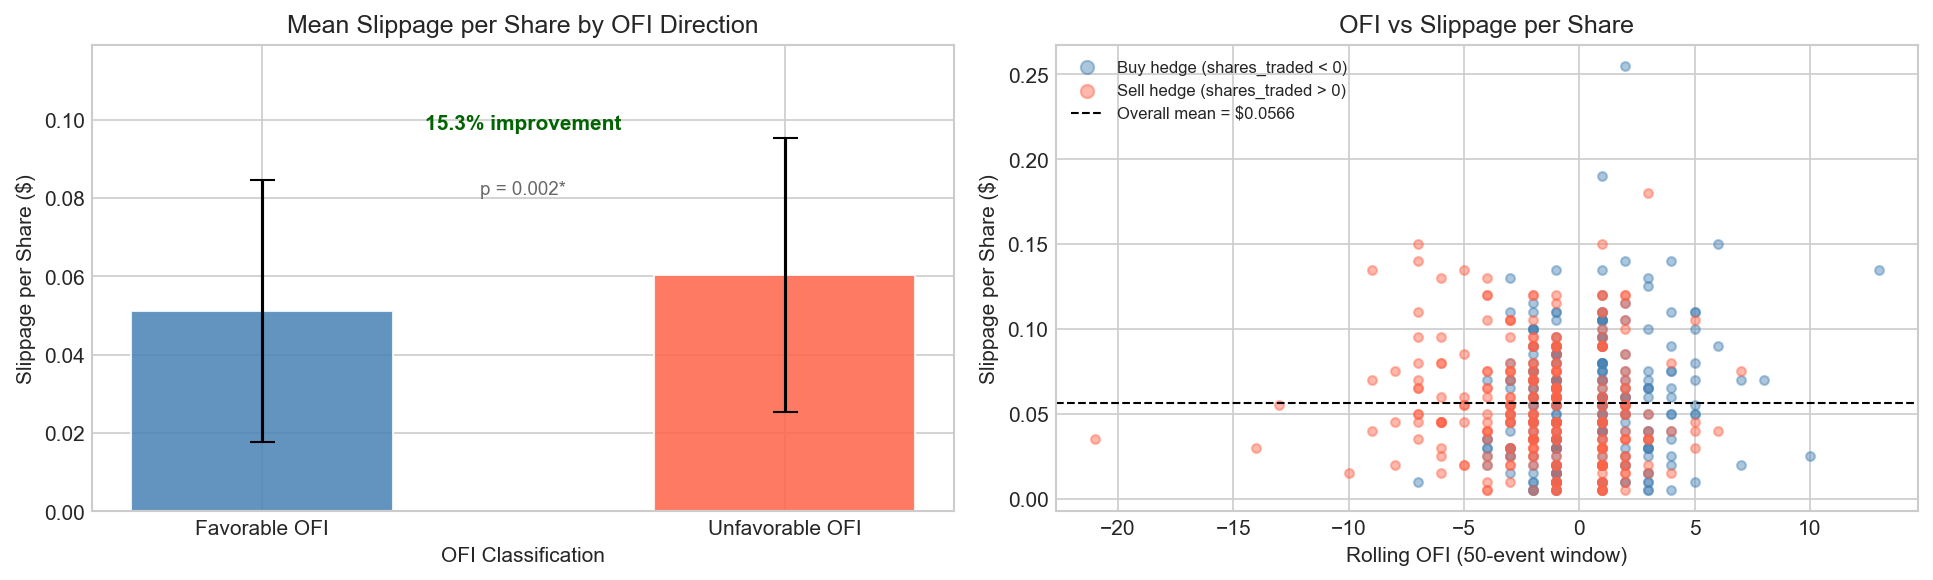

In [ ]:
# OFI timing analysis
ofi_results = analyze_ofi(save_fig=True)

fav   = ofi_results['favorable']
unfav = ofi_results['unfavorable']

print('\n=== OFI Results ===')
res_df = pd.DataFrame({
    'Metric':          ['Count', 'Mean slip/share ($)', 'Median slip/share ($)', 'Total slippage ($)'],
    'Favorable OFI':   [fav['count'],   f"{fav['mean']:.4f}",   f"{fav['median']:.4f}",   f"{fav['total']:.4f}"],
    'Unfavorable OFI': [unfav['count'], f"{unfav['mean']:.4f}", f"{unfav['median']:.4f}", f"{unfav['total']:.4f}"],
})
print(res_df.to_string(index=False))
print(f"\nSlippage improvement : {ofi_results['pct_improvement']:.1f}%")
print(f"t-statistic          : {ofi_results['t_statistic']:.3f}")
print(f"p-value              : {ofi_results['p_value']:.4f}")

from IPython.display import Image, display
display(Image('../results/figures/ofi_analysis.png'))

**Interpretation.** When the engine executes hedges with order flow aligned to the trade direction, it achieves lower slippage per share. This is a pure execution-timing effect; the hedge decision itself is unchanged. Even a small per-share improvement compounds significantly across hundreds of hedges per day and across a portfolio of many positions.

Running frontier sweep — this will take ~1-2 minutes...

Running frontier sweep over 8 lambda values...
  Engine : ../engine/hedger
  Data   : ../data/raw/AAPL-Lobster-Orderbook.csv

  Lambda  0.10: 1185 hedges, net P&L $ -97.36, tcost $ 87.83, δ-gap var 0.1119
  Lambda  0.25:  959 hedges, net P&L $ -73.82, tcost $ 65.21, δ-gap var 0.1170
  Lambda  0.50:  812 hedges, net P&L $ -59.09, tcost $ 51.45, δ-gap var 0.1384
  Lambda  1.00:  665 hedges, net P&L $ -48.18, tcost $ 38.04, δ-gap var 0.1846
  Lambda  2.00:  519 hedges, net P&L $ -35.63, tcost $ 26.05, δ-gap var 0.2123
  Lambda  5.00:  365 hedges, net P&L $ -23.84, tcost $ 13.39, δ-gap var 0.2411
  Lambda 10.00:  261 hedges, net P&L $ -18.16, tcost $  7.69, δ-gap var 0.5602
  Lambda 20.00:  199 hedges, net P&L $ -13.64, tcost $  3.90, δ-gap var 0.6449

Frontier results saved → ../data/processed/frontier_results.csv

=== Frontier Results ===
 lambda_val  total_hedges  net_pnl  total_tcost  net_pnl  greek_net_pnl  total_theta_pnl  tota

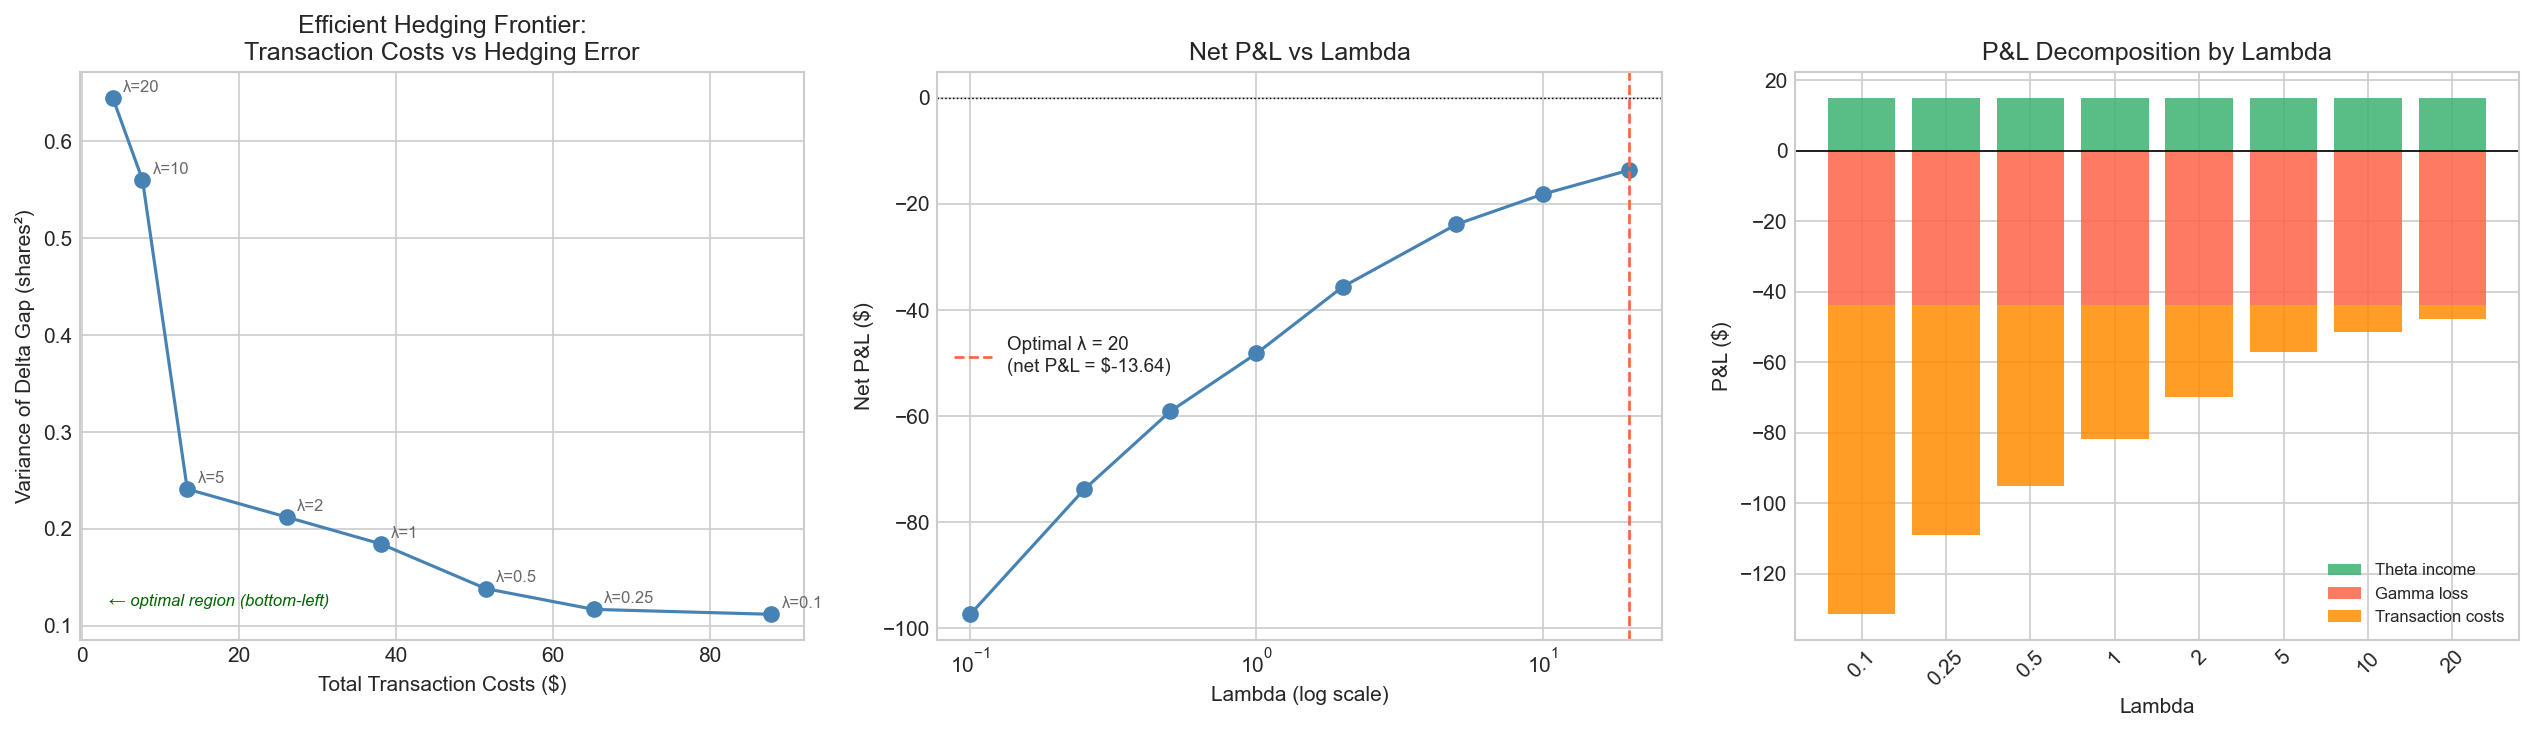

In [ ]:
# run efficient frontier
print('Running frontier sweep — this will take ~1-2 minutes...\n')
frontier_df = run_frontier(
    ob_file='../data/raw/AAPL-Lobster-Orderbook.csv',
    msg_file='../data/raw/AAPL-Lobster-Message.csv',
    engine_path='../engine/hedger',
)

print('\n=== Frontier Results ===')
display_cols = ['lambda_val', 'total_hedges', 'net_pnl',
                'total_tcost', 'net_pnl', 'greek_net_pnl', 'total_theta_pnl', 'total_gamma_pnl', 'delta_gap_variance']
print(frontier_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

plot_frontier(frontier_df, save_fig=True)

from IPython.display import Image, display
display(Image('../results/figures/efficient_frontier.png'))

Summary figure saved → ../results/figures/summary_figure.png


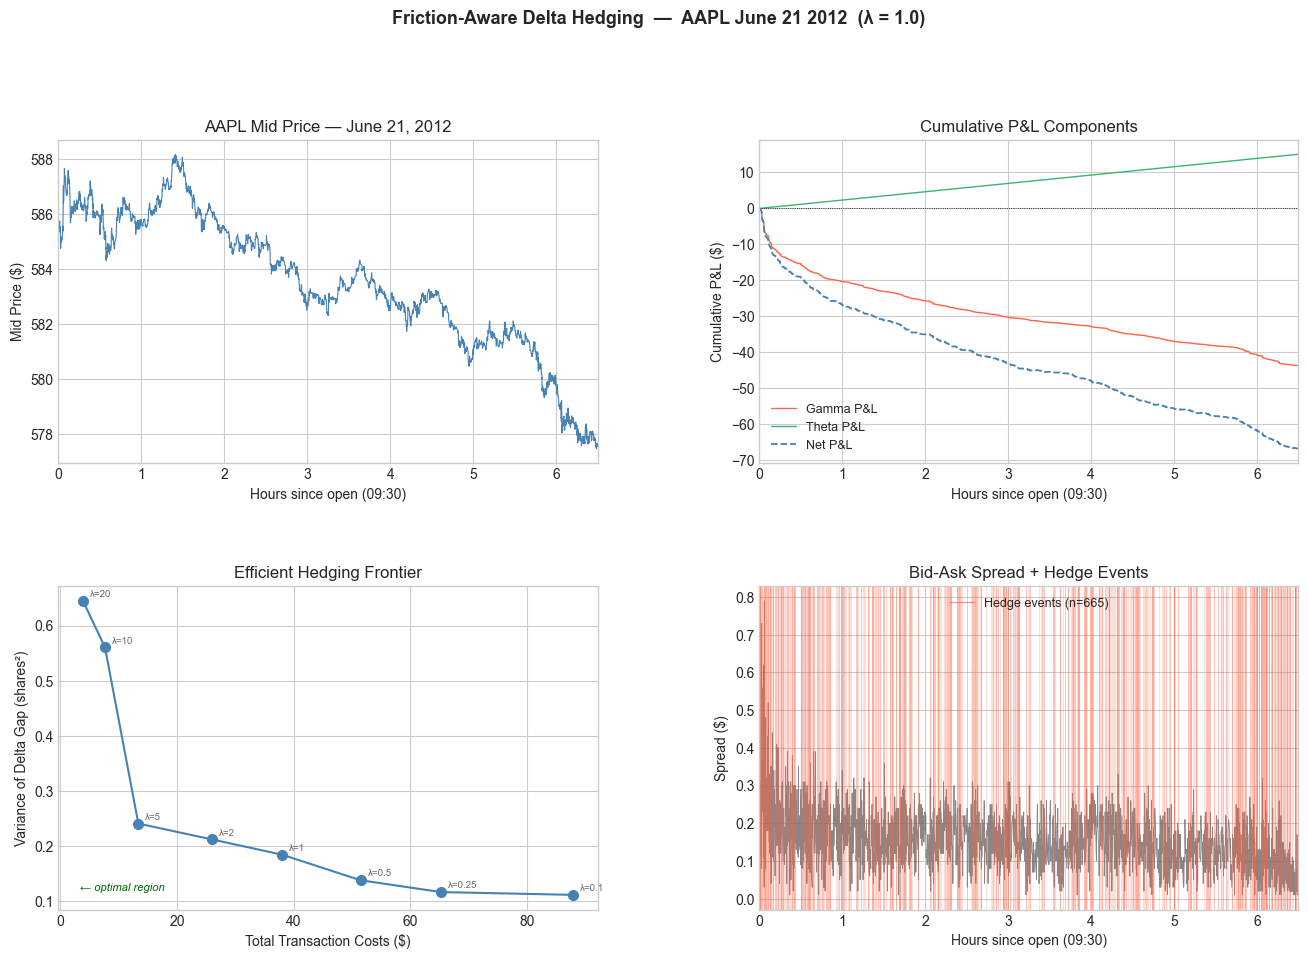

In [ ]:
# four-panel summary figure
plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# subsample tick_log to ~3000 points for clean line plots
step = max(1, len(tick_log) // 3000)
tl   = tick_log.iloc[::step].copy()
hrs  = (tl['timestamp'] - 34200) / 3600

# AAPL mid price (panel 1)
ax1.plot(hrs, tl['mid_price'], color='steelblue', linewidth=0.8)
ax1.set_title('AAPL Mid Price — June 21, 2012')
ax1.set_xlabel('Hours since open (09:30)')
ax1.set_ylabel('Mid Price ($)')
ax1.set_xlim(0, 6.5)

# cumulative P&L lines (panel 2)
net_cum = tl['cumulative_gamma_pnl'] + tl['cumulative_theta_pnl'] - tl['cumulative_tcost']
ax2.plot(hrs, tl['cumulative_gamma_pnl'],  color='tomato',         linewidth=1.0, label='Gamma P&L')
ax2.plot(hrs, tl['cumulative_theta_pnl'],  color='mediumseagreen', linewidth=1.0, label='Theta P&L')
ax2.plot(hrs, net_cum,                     color='steelblue',      linewidth=1.3, linestyle='--', label='Net P&L')
ax2.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax2.set_title('Cumulative P&L Components')
ax2.set_xlabel('Hours since open (09:30)')
ax2.set_ylabel('Cumulative P&L ($)')
ax2.set_xlim(0, 6.5)
ax2.legend(fontsize=9)

# efficient frontier (panel 3)
try:
    fr = pd.read_csv('../data/processed/frontier_results.csv')
    ax3.plot(fr['total_tcost'], fr['delta_gap_variance'],
             'o-', color='steelblue', linewidth=1.5, markersize=7)
    for _, row in fr.iterrows():
        ax3.annotate(f"\u03bb={row['lambda_val']:.2g}",
                     xy=(row['total_tcost'], row['delta_gap_variance']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7, color='dimgray')
    ax3.annotate('\u2190 optimal region', xy=(0.04, 0.06), xycoords='axes fraction',
                 fontsize=8, color='darkgreen', style='italic')
except FileNotFoundError:
    ax3.text(0.5, 0.5, 'Run Cell 6 first\n(frontier_results.csv not found)',
             ha='center', va='center', transform=ax3.transAxes, color='dimgray')
ax3.set_title('Efficient Hedging Frontier')
ax3.set_xlabel('Total Transaction Costs ($)')
ax3.set_ylabel('Variance of Delta Gap (shares\u00b2)')

# hedge events (panel 4)
ax4.plot(hrs, tl['spread'], color='dimgray', linewidth=0.6, alpha=0.8)
hedge_rows = tick_log[tick_log['hedged'] == 1]
hedge_hrs  = (hedge_rows['timestamp'] - 34200) / 3600
for h in hedge_hrs:
    ax4.axvline(h, color='tomato', alpha=0.25, linewidth=0.6)
if len(hedge_hrs) > 0:
    ax4.axvline(hedge_hrs.iloc[0], color='tomato', alpha=0.7, linewidth=0.8,
                label=f'Hedge events (n={len(hedge_hrs)})')
ax4.set_title('Bid-Ask Spread + Hedge Events')
ax4.set_xlabel('Hours since open (09:30)')
ax4.set_ylabel('Spread ($)')
ax4.set_xlim(0, 6.5)
ax4.legend(fontsize=9)

fig.suptitle('Friction-Aware Delta Hedging  —  AAPL June 21 2012  (λ = 1.0)',
             fontsize=13, fontweight='bold', y=1.01)

path = '../results/figures/summary_figure.png'
fig.savefig(path, dpi=150, bbox_inches='tight')
print(f'Summary figure saved → {path}')
plt.show()